In [78]:
import pandas as pd 

In [79]:
df = pd.read_csv('REC.csv')
df

,Month,Total Energy Consumed by the Residential Sector
0,1973-01-01,1957.641
1,1973-02-01,1712.143
2,1973-03-01,1510.079
3,1973-04-01,1183.421
4,1973-05-01,1006.326
...,...,...
583,2021-08-01,1755.212
584,2021-09-01,1456.901
585,2021-10-01,1315.799
586,2021-11-01,1644.306


In [80]:
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m-%d')
df

,Month,Total Energy Consumed by the Residential Sector
0,1973-01-01,1957.641
1,1973-02-01,1712.143
2,1973-03-01,1510.079
3,1973-04-01,1183.421
4,1973-05-01,1006.326
...,...,...
583,2021-08-01,1755.212
584,2021-09-01,1456.901
585,2021-10-01,1315.799
586,2021-11-01,1644.306


In [81]:
df.columns = ["Date","Energy"]

In [82]:
df

,Date,Energy
0,1973-01-01,1957.641
1,1973-02-01,1712.143
2,1973-03-01,1510.079
3,1973-04-01,1183.421
4,1973-05-01,1006.326
...,...,...
583,2021-08-01,1755.212
584,2021-09-01,1456.901
585,2021-10-01,1315.799
586,2021-11-01,1644.306


In [83]:
df['Enegy_last_month_1'] = df['Energy'].shift(1)
df['Enegy_last_month_2'] = df['Energy'].shift(2)
df['Enegy_last_month_3'] = df['Energy'].shift(3)
df['Enegy_last_month_4'] = df['Energy'].shift(4)
df['Enegy_last_month_5'] = df['Energy'].shift(5)
df['Enegy_last_month_6'] = df['Energy'].shift(6)
df = df.dropna()
df

,Date,Energy,Enegy_last_month_1,Enegy_last_month_2,Enegy_last_month_3,Enegy_last_month_4,Enegy_last_month_5,Enegy_last_month_6
6,1973-07-01,961.872,914.949,1006.326,1183.421,1510.079,1712.143,1957.641
7,1973-08-01,994.259,961.872,914.949,1006.326,1183.421,1510.079,1712.143
8,1973-09-01,937.083,994.259,961.872,914.949,1006.326,1183.421,1510.079
9,1973-10-01,978.162,937.083,994.259,961.872,914.949,1006.326,1183.421
10,1973-11-01,1202.105,978.162,937.083,994.259,961.872,914.949,1006.326
...,...,...,...,...,...,...,...,...
583,2021-08-01,1755.212,1737.442,1564.205,1358.566,1397.144,1856.031,2350.977
584,2021-09-01,1456.901,1755.212,1737.442,1564.205,1358.566,1397.144,1856.031
585,2021-10-01,1315.799,1456.901,1755.212,1737.442,1564.205,1358.566,1397.144
586,2021-11-01,1644.306,1315.799,1456.901,1755.212,1737.442,1564.205,1358.566


In [84]:
import numpy as np

In [85]:
pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [86]:
X = df.drop(['Date','Energy'], axis=1)
y = df['Energy']

In [87]:
X

,Enegy_last_month_1,Enegy_last_month_2,Enegy_last_month_3,Enegy_last_month_4,Enegy_last_month_5,Enegy_last_month_6
6,914.949,1006.326,1183.421,1510.079,1712.143,1957.641
7,961.872,914.949,1006.326,1183.421,1510.079,1712.143
8,994.259,961.872,914.949,1006.326,1183.421,1510.079
9,937.083,994.259,961.872,914.949,1006.326,1183.421
10,978.162,937.083,994.259,961.872,914.949,1006.326
...,...,...,...,...,...,...
583,1737.442,1564.205,1358.566,1397.144,1856.031,2350.977
584,1755.212,1737.442,1564.205,1358.566,1397.144,1856.031
585,1456.901,1755.212,1737.442,1564.205,1358.566,1397.144
586,1315.799,1456.901,1755.212,1737.442,1564.205,1358.566


In [88]:
from xgboost import XGBRegressor

In [89]:
model = XGBRegressor()
model.fit(X,y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [90]:
pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Text(0.5, 0, 'Date')

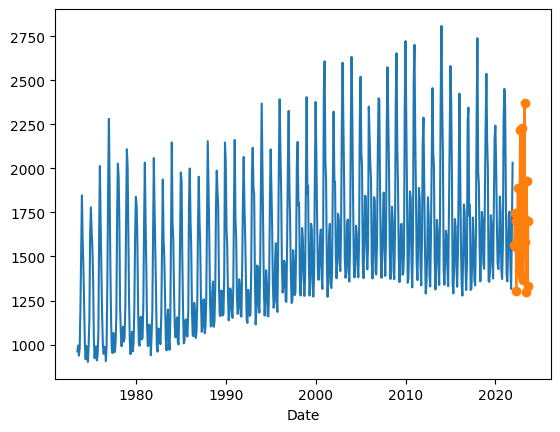

In [91]:
# test next 6 month
import matplotlib.pyplot as plt


plt.plot(df['Date'], df['Energy'], label='Actual')
future_dates = pd.date_range(start=df['Date'].iloc[-1] + pd.DateOffset(months=1), periods=20, freq='ME')
future_predictions = []
last_known_values = df['Energy'].iloc[-6:].values
for i in range(20):
    future_predictions.append(model.predict([last_known_values])[0])
    last_known_values = np.roll(last_known_values, -1)
    last_known_values[-1] = future_predictions[-1]
plt.plot(future_dates, future_predictions, label='Predicted', marker='o')
plt.xlabel('Date')
